# Test neuromodes eigenstrapping vs original eigenstrapping

This notebook compares the `nulls.eigenstrap` implementation against the original `eigenstrapping.SurfaceEigenstrapping` class to verify correctness. The original implementation can be found [here](https://github.com/nikitas-k/eigenstrapping).

To match the default version of the original implementation of eigenstrapping, users must run `nulls.eigenstrap` with the following:
- Ensure `data` has a mean of zero.
- Set `resample="range"`
- Set `decomp_method="regress"`
- Set `rotation_method="scipy"`
- Set `seed=seed`

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from importlib.resources import files
from pathlib import Path
from packaging import version

from neuromodes import EigenSolver
from neuromodes.nulls import eigenstrap
from neuromodes.io import fetch_surf, fetch_map

from nsbutils.plotting import plot_surf
from nsbutils.utils import unmask

In [2]:
density = '4k'
hemi = 'L'

surf_type = 'midthickness'
mesh, medmask = fetch_surf(density=density, hemi='L', surf_type='midthickness')
mesh_file = files('neuromodes.data') / f'sp-human_tpl-fsLR_den-{density}_hemi-{hemi}_{surf_type}.surf.gii'

map = fetch_map('myelinmap', density=density)[medmask]
map = (map - np.mean(map)) # to match original implementation which doesn't use the constant mode

In [3]:
n_modes = 10**2 # first 10 eigengroups
n_nulls = 100
seed = 365

We start by computing the eigenmodes and eigenvalues to use for both implementations.

In [4]:
solver = EigenSolver(mesh, mask=medmask).solve(n_modes, fix_mode1=True)
evals = solver.evals
emodes = solver.emodes

We can compute nulls using the original `eigenstrapping.SurfaceEigenstrapping` class. This package is a bit unstable so we just load pre-computed nulls using the original implementation for now. Should the user want to generate the nulls themself they can just install the package and uncomment the code below.

In [5]:
# from eigenstrapping import SurfaceEigenstrapping

# # Generate nulls with eigenstrapping
# print("Generating nulls with eigenstrapping...")
# np.random.seed(seed)  # Set global seed for consistency
# t1 = time.time()
# eigen_orig = SurfaceEigenstrapping(
#     data=map,
#     emodes=emodes[:, 1:],
#     evals=evals[1:],
#     num_modes=n_modes,
#     seed=seed,
# )
# nulls_orig = eigen_orig(n=n_nulls).T
# t2 = time.time()
# print(f"{t2 - t1:.2f} seconds for {n_nulls} nulls.")

# print(f"eigenstrapping nulls shape: {nulls_orig.shape}")
# print(f"eigenstrapping nulls range: [{nulls_orig.min():.3f}, {nulls_orig.max():.3f}]")

In [6]:
# Load precomputed nulls using original implementation (comment this out if running original code)

# `scipy.stats.special_ortho_group.rvs` was updated in scipy=1.16.0 such that it generates different 
# rotation matrices. 
import scipy
if version.parse(scipy.__version__) < version.parse('1.16.0'):
    scipy_version = '1.15.3'
else:
    scipy_version = '1.16.0'
print(f"Loading original nulls for scipy version: {scipy_version}")

test_data_dir = Path.cwd().parent.parent / "tests/test_data"
nulls_file = f"sp-human_tpl-fsLR_den-{density}_hemi-{hemi}_midthickness_eigenstrap-nulls-orig_scipy={scipy_version}.npy"
nulls_orig = np.load(test_data_dir / nulls_file)

Loading original nulls for scipy version: 1.15.3


Now we can compute nulls using `nulls.eigenstrap`.

In [7]:
# Generate nulls with neuromodes
print("Generating normalized nulls with neuromodes...")
t1 = time.time()
nulls_neuromodes = eigenstrap(
    data=map,
    emodes=emodes, 
    evals=evals,
    n_nulls=n_nulls,
    seed=seed,                  # to match original seed=seed 
    residual=None,              # to match original add_res=False and permute=False
    resample="range",           # to match original resample=False
    decomp_method="regress",    # to match original decomp_method='matrix'
    rotation_method="scipy",    # to match original rotations.indirect_method (called by geometry.gen_eigensamples)
)
t2 = time.time()
print(f"{t2 - t1:.2f} seconds for {n_nulls} nulls.")

print(f"neuromodes nulls shape: {nulls_neuromodes.shape}")
print(f"neuromodes nulls range: [{nulls_neuromodes.min():.3f}, {nulls_neuromodes.max():.3f}]")

Generating normalized nulls with neuromodes...
0.13 seconds for 100 nulls.
neuromodes nulls shape: (3619, 100)
neuromodes nulls range: [-0.335, 0.542]


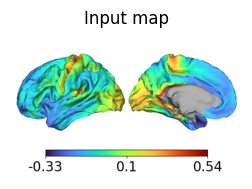

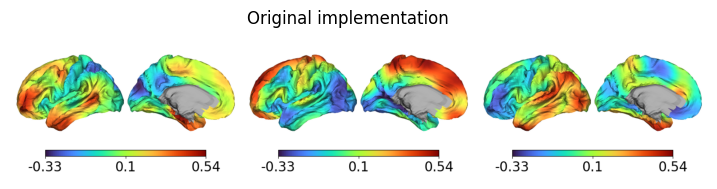

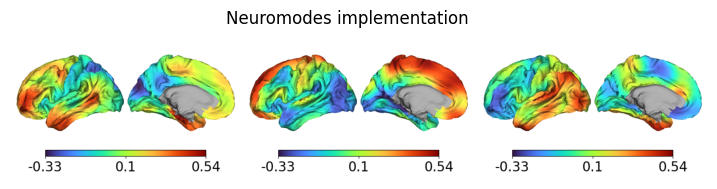

In [8]:
fig1 = plot_surf(
    mesh=mesh_file,
    data=unmask(map, medmask),
    cmap='turbo',
    cbar=True
)
plt.title("Input map")

plot_surf(
    mesh=mesh_file,
    data=unmask(nulls_orig[:, :3], medmask),
    cmap='turbo',
    cbar=True
)
# plt.suptitle("Neuromodes nulls (non-normalized)")
plt.suptitle("Original implementation")

plot_surf(
    mesh=mesh_file,
    data=unmask(nulls_neuromodes[:, :3], medmask),
    cmap='turbo',
    cbar=True
)
# plt.suptitle("Neuromodes nulls (normalized)")
plt.suptitle("Neuromodes implementation")

plt.show()

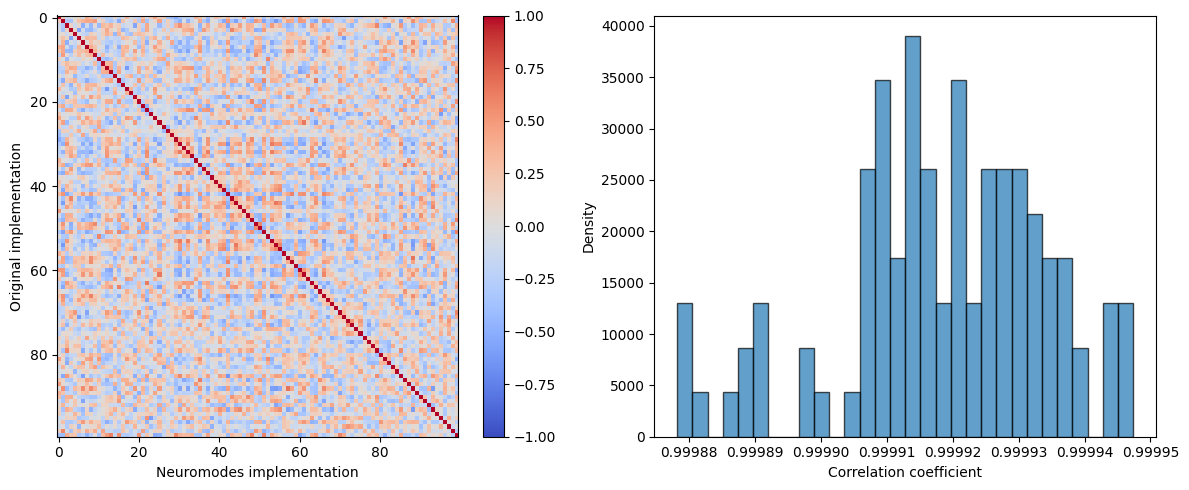

In [9]:
null_corrs = np.corrcoef(nulls_neuromodes.T, nulls_orig.T)[:n_nulls, n_nulls:]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap using matplotlib
im = axs[0].imshow(null_corrs, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
fig.colorbar(im, ax=axs[0])
axs[0].set_xlabel("Neuromodes implementation")
axs[0].set_ylabel("Original implementation")

# Histogram
diagonal_corrs = np.diagonal(null_corrs)
axs[1].hist(diagonal_corrs, bins=30, density=True, alpha=0.7, edgecolor='black')

axs[1].set_xlabel("Correlation coefficient")
axs[1].set_ylabel("Density")
axs[1].locator_params(axis='x', nbins=8)

plt.tight_layout()
plt.show()